# Validation Inspector
Load a model snapshot, run any val sample through it, and visualize registration + morph quality.

In [1]:
import os, sys

EXP_DIR = os.path.dirname(os.path.abspath('__file__'))
ROOT_DIR = os.path.dirname(os.path.dirname(EXP_DIR))
sys.path.insert(0, EXP_DIR)
sys.path.insert(0, ROOT_DIR)
os.chdir(EXP_DIR)

# ── USER CONFIG ──────────────────────────────────────────────────────────────
SNAPSHOT_PATH = os.path.join(
    ROOT_DIR, 'output',
    'geotransformer.facesdownsampledfixed.stage4.gse.k3.max.oacl.stage2.sinkhorn',
    'snapshots', 'snapshot.pth.tar'
)
VAL_SAMPLE_IDX    = 0    # which val sample to inspect (0-indexed)
VAL_AUG_SCALE     = 1.0  # fixed scale for val augmentation
VAL_AUG_SUBSAMPLE = 1.0
DEVICE = 'cuda'
# ─────────────────────────────────────────────────────────────────────────────

print('EXP_DIR :', EXP_DIR)
print('ROOT_DIR:', ROOT_DIR)
print('Snapshot:', SNAPSHOT_PATH)

EXP_DIR : /workspace/src/experiments/geotransformer.faces.stage4.gse.k3.max.oacl.stage2.sinkhorn
ROOT_DIR: /workspace/src
Snapshot: /workspace/src/output/geotransformer.facesdownsampledfixed.stage4.gse.k3.max.oacl.stage2.sinkhorn/snapshots/snapshot.pth.tar


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from config_dowsampled import make_cfg
from dataset import train_valid_data_loader
from model import create_model
from loss import OverallLoss, Evaluator

cfg = make_cfg()
print('Config loaded')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Config loaded


In [3]:
# Build val loader (also calibrates neighbor_limits from train set)
_, val_loader, neighbor_limits = train_valid_data_loader(
    cfg, distributed=False,
    val_aug_scale=VAL_AUG_SCALE,
    val_aug_subsample=VAL_AUG_SUBSAMPLE,
)
print('neighbor_limits:', neighbor_limits)
print('Val samples    :', len(val_loader.dataset))

neighbor_limits: [58 24 28 30]
Val samples    : 500


In [4]:
# Build model and load snapshot
model = create_model(cfg).to(DEVICE)
model.neighbor_limits = neighbor_limits

ckpt = torch.load(SNAPSHOT_PATH, map_location=DEVICE)
state_dict = ckpt.get('model', ckpt)  # handle both raw state_dict and trainer checkpoint
# Strip 'module.' prefix if saved from DDP
state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict, strict=True)
model.eval()

loss_fn   = OverallLoss(cfg).to(DEVICE)
evaluator = Evaluator(cfg).to(DEVICE)

epoch_in_ckpt = ckpt.get('epoch', '?')
print(f'Loaded snapshot (epoch {epoch_in_ckpt})')

Loaded snapshot (epoch 40)


In [5]:
# Pull the requested sample and collate it into a batch-of-1
from functools import partial
from geotransformer.utils.data import registration_collate_fn_stack_mode

collate_fn = partial(
    registration_collate_fn_stack_mode,
    num_stages=cfg.backbone.num_stages,
    voxel_size=cfg.backbone.init_voxel_size,
    search_radius=cfg.backbone.init_radius,
    neighbor_limits=neighbor_limits,
    precompute_data=False,
)

val_dataset = val_loader.dataset
raw_sample  = val_dataset[VAL_SAMPLE_IDX]
data_dict   = collate_fn([raw_sample])

# Move all tensors to DEVICE
for k, v in data_dict.items():
    if isinstance(v, torch.Tensor):
        data_dict[k] = v.to(DEVICE)
    elif isinstance(v, list) and len(v) > 0 and isinstance(v[0], torch.Tensor):
        data_dict[k] = [t.to(DEVICE) for t in v]

gt_scale = data_dict.get('gt_scale', None)
print(f'Sample index : {VAL_SAMPLE_IDX}')
print(f'GT scale     : {gt_scale.item():.4f}' if gt_scale is not None else 'GT scale: N/A')
print(f'Points shape : {data_dict["points"].shape}')

Sample index : 0
GT scale     : 1.0000
Points shape : torch.Size([13247, 3])


In [6]:
# Forward pass
with torch.no_grad():
    output_dict = model(data_dict)

pred_scale   = output_dict['pred_scale'].item()
gt_scale_val = data_dict['gt_scale'].item() if 'gt_scale' in data_dict else float('nan')
print(f'pred_scale : {pred_scale:.4f}')
print(f'gt_scale   : {gt_scale_val:.4f}')

# Losses
loss_dict = loss_fn(output_dict, data_dict, epoch=999, mode='val')
m_loss = loss_dict['m_loss'].item()
s_loss = loss_dict['s_loss'].item()
c_loss = loss_dict['c_loss'].item()
f_loss = loss_dict['f_loss'].item()

# Registration metrics
eval_dict = evaluator(output_dict, data_dict)
rre  = eval_dict['RRE'].item()
rte  = eval_dict['RTE'].item()
rmse = eval_dict['RMSE'].item()
rr   = eval_dict['RR'].item()
pir  = eval_dict['PIR'].item()
ir   = eval_dict['IR'].item()

print()
print('─── Registration ───────────────────')
print(f'  RRE  : {rre:.3f}°')
print(f'  RTE  : {rte:.4f} m')
print(f'  RMSE : {rmse:.4f} m')
print(f'  RR   : {rr:.3f}')
print(f'  PIR  : {pir:.3f}')
print(f'  IR   : {ir:.3f}')
print()
print('─── Losses ─────────────────────────')
print(f'  morph_loss  : {m_loss:.6f}')
print(f'  scale_loss  : {s_loss:.6f}')
print(f'  coarse_loss : {c_loss:.6f}')
print(f'  fine_loss   : {f_loss:.6f}')

pred_scale : 1.0509
gt_scale   : 1.0000

─── Registration ───────────────────
  RRE  : 0.988°
  RTE  : 0.0776 m
  RMSE : 0.0761 m
  RR   : 1.000
  PIR  : 0.301
  IR   : 0.515

─── Losses ─────────────────────────
  morph_loss  : 0.007903
  scale_loss  : 0.050874
  coarse_loss : 0.643902
  fine_loss   : 0.755650


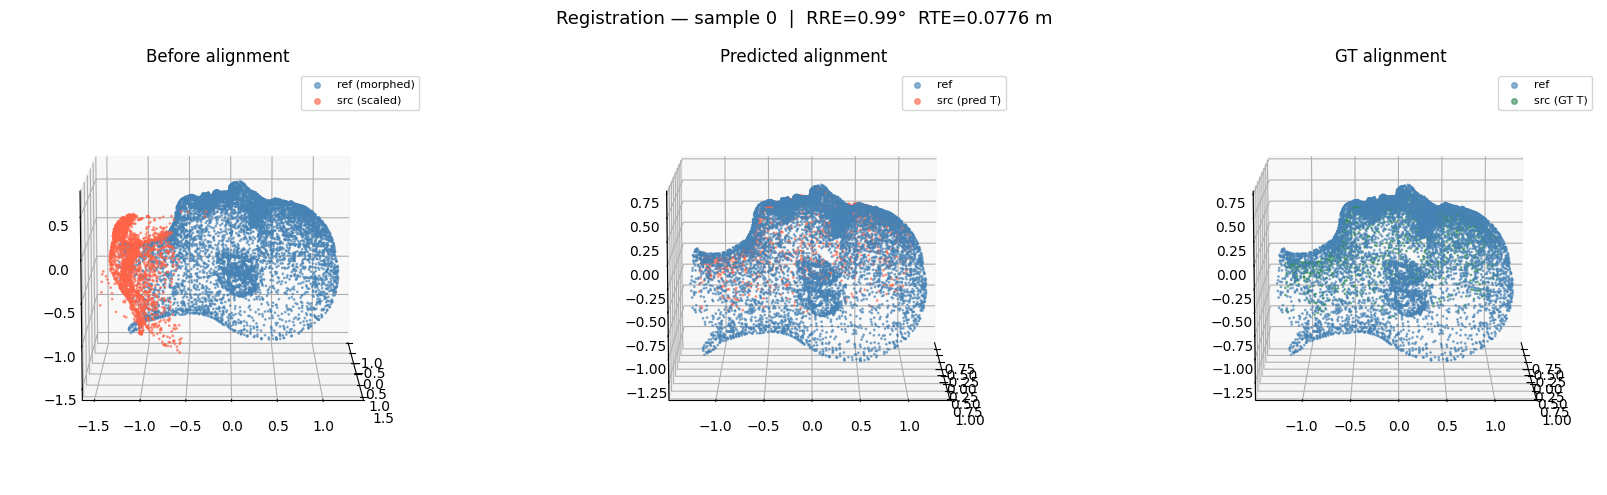

In [7]:
# ── Visualize Registration ────────────────────────────────────────────────────
from geotransformer.modules.ops.transformation import apply_transform

ref_pts        = output_dict['ref_points'].cpu().numpy()
src_pts        = output_dict['src_points'].cpu().numpy()
est_tf         = output_dict['estimated_transform']
gt_tf          = data_dict['transform']
src_aligned    = apply_transform(output_dict['src_points'], est_tf).cpu().numpy()
src_gt_aligned = apply_transform(output_dict['src_points'], gt_tf).cpu().numpy()

def scatter3(ax, pts, color, s=1, label=None):
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=color, s=s, label=label, alpha=0.6)

fig = plt.figure(figsize=(18, 5))
fig.suptitle(
    f'Registration — sample {VAL_SAMPLE_IDX}  |  RRE={rre:.2f}°  RTE={rte:.4f} m',
    fontsize=13
)

ax1 = fig.add_subplot(131, projection='3d')
scatter3(ax1, ref_pts, 'steelblue', label='ref (morphed)')
scatter3(ax1, src_pts, 'tomato',    label='src (scaled)')
ax1.set_title('Before alignment')
ax1.legend(markerscale=4, fontsize=8)
ax1.view_init(elev=10, azim=0)

ax2 = fig.add_subplot(132, projection='3d')
scatter3(ax2, ref_pts,     'steelblue', label='ref')
scatter3(ax2, src_aligned, 'tomato',    label='src (pred T)')
ax2.set_title('Predicted alignment')
ax2.legend(markerscale=4, fontsize=8)
ax2.view_init(elev=10, azim=0)

ax3 = fig.add_subplot(133, projection='3d')
scatter3(ax3, ref_pts,        'steelblue', label='ref')
scatter3(ax3, src_gt_aligned, 'seagreen',  label='src (GT T)')
ax3.set_title('GT alignment')
ax3.legend(markerscale=4, fontsize=8)
ax3.view_init(elev=10, azim=0)

plt.tight_layout()
plt.show()

In [8]:

# ── Interactive registration viewer (plotly, drag in-notebook) ────────────────
import plotly.graph_objects as go

def pcd_trace(pts, color, name, size=2, opacity=0.7):
    return go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode='markers',
        marker=dict(size=size, color=color, opacity=opacity),
        name=name,
    )

def show_reg(traces, title):
    fig = go.Figure(data=traces)
    fig.update_layout(
        title=title, height=600,
        scene=dict(aspectmode='data'),
        legend=dict(itemsizing='constant'),
        margin=dict(l=0, r=0, b=0, t=40),
    )
    fig.show()

show_reg(
    [pcd_trace(ref_pts, 'steelblue', 'ref (morphed)'),
     pcd_trace(src_pts, 'tomato',    'src (unaligned)')],
    f'Before alignment — sample {VAL_SAMPLE_IDX}',
)

show_reg(
    [pcd_trace(ref_pts,     'steelblue', 'ref'),
     pcd_trace(src_aligned, 'orange',    f'src pred  RRE={rre:.2f}° RTE={rte:.4f}m')],
    f'Predicted alignment — sample {VAL_SAMPLE_IDX}',
)

show_reg(
    [pcd_trace(ref_pts,        'steelblue', 'ref'),
     pcd_trace(src_gt_aligned, 'seagreen',  'src GT transform')],
    f'GT alignment — sample {VAL_SAMPLE_IDX}',
)


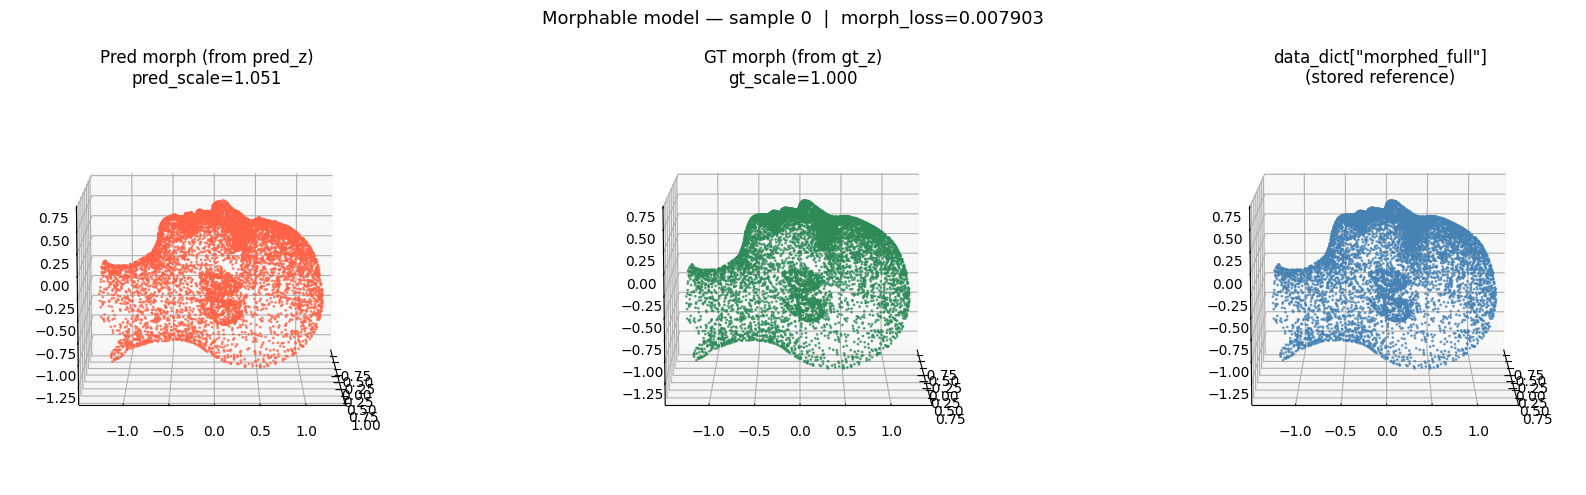

In [9]:
# ── Visualize Morphed Ref vs GT Morphed Ref ───────────────────────────────────
pred_morph = output_dict['morphed_full'].cpu().numpy()
gt_morph   = output_dict['recon_gt_points'].cpu().numpy()  # reconstructed from gt_z
data_morph = data_dict.get('morphed_full', None)
if data_morph is not None:
    data_morph = data_morph.cpu().numpy()

ncols = 3 if data_morph is not None else 2
fig2, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5),
                          subplot_kw={'projection': '3d'})
fig2.suptitle(
    f'Morphable model — sample {VAL_SAMPLE_IDX}  |  morph_loss={m_loss:.6f}',
    fontsize=13
)

axes[0].scatter(pred_morph[:, 0], pred_morph[:, 1], pred_morph[:, 2],
                c='tomato', s=1, alpha=0.7)
axes[0].set_title(f'Pred morph (from pred_z)\npred_scale={pred_scale:.3f}')
axes[0].view_init(elev=10, azim=0)

axes[1].scatter(gt_morph[:, 0], gt_morph[:, 1], gt_morph[:, 2],
                c='seagreen', s=1, alpha=0.7)
axes[1].set_title(f'GT morph (from gt_z)\ngt_scale={gt_scale_val:.3f}')
axes[1].view_init(elev=10, azim=0)

if data_morph is not None:
    axes[2].scatter(data_morph[:, 0], data_morph[:, 1], data_morph[:, 2],
                    c='steelblue', s=1, alpha=0.7)
    axes[2].set_title('data_dict["morphed_full"]\n(stored reference)')
    axes[2].view_init(elev=10, azim=0)

plt.tight_layout()
plt.show()

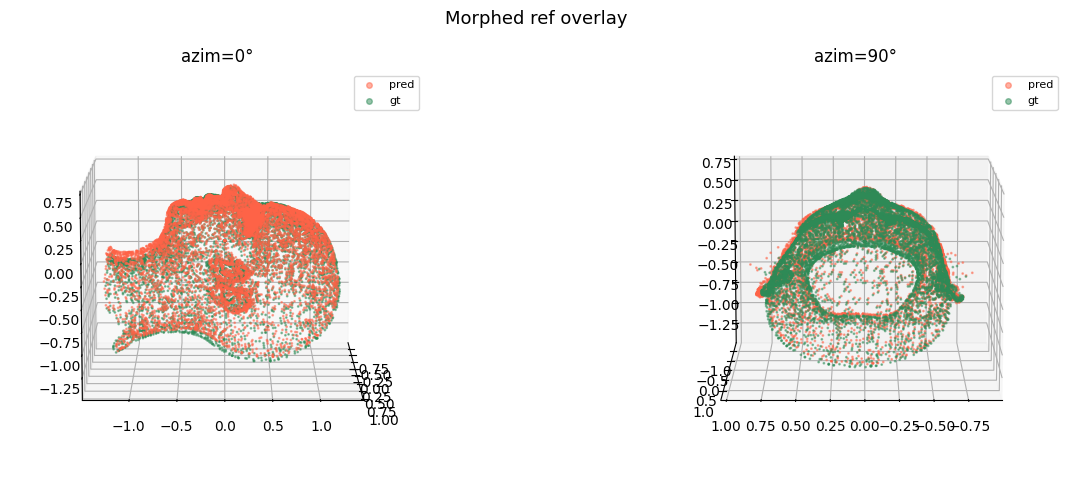

In [10]:
# ── Overlay: pred morph vs gt morph from two viewpoints ──────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={'projection': '3d'})
fig3.suptitle('Morphed ref overlay', fontsize=13)

for ax, azim in zip(axes3, [0, 90]):
    ax.scatter(pred_morph[:, 0], pred_morph[:, 1], pred_morph[:, 2],
               c='tomato', s=1, alpha=0.5, label='pred')
    ax.scatter(gt_morph[:, 0], gt_morph[:, 1], gt_morph[:, 2],
               c='seagreen', s=1, alpha=0.5, label='gt')
    ax.set_title(f'azim={azim}°')
    ax.view_init(elev=10, azim=azim)
    ax.legend(markerscale=4, fontsize=8)

plt.tight_layout()
plt.show()

In [11]:

# ── Interactive morph viewer (plotly) ─────────────────────────────────────────
show_reg(
    [pcd_trace(pred_morph, 'tomato',   f'pred morph  scale={pred_scale:.3f}'),
     pcd_trace(gt_morph,   'seagreen', f'GT morph    scale={gt_scale_val:.3f}')],
    f'Morphed ref overlay — morph_loss={m_loss:.6f}  sample {VAL_SAMPLE_IDX}',
)

if data_morph is not None:
    show_reg(
        [pcd_trace(pred_morph, 'tomato',    'pred morph'),
         pcd_trace(data_morph, 'steelblue', 'data_dict morphed_full')],
        f'Pred morph vs stored reference — sample {VAL_SAMPLE_IDX}',
    )


---
## Real scan inference
No ground truth — qualitative visualization only.

In [12]:

# ── USER CONFIG ───────────────────────────────────────────────────────────────
REAL_SCAN_PATH = os.path.join(EXP_DIR, 'plank_scaled.npy')
# ─────────────────────────────────────────────────────────────────────────────

# Load real scan
src_raw = np.load(REAL_SCAN_PATH)
src_real_pts = torch.from_numpy(src_raw[:, :3]).float().to(DEVICE)
print(f'Real scan loaded: {src_real_pts.shape}')

# Mean reference face = generate_reference_geometry with z=0
with torch.no_grad():
    mean_ref_pts = model.generate_reference_geometry(
        torch.zeros(32, 100, device=DEVICE)
    )
mean_ref_np = mean_ref_pts.cpu().numpy()
print(f'Mean ref face   : {mean_ref_pts.shape}')


Real scan loaded: torch.Size([2000, 3])
Mean ref face   : torch.Size([10788, 3])


In [13]:

# Build minimal data_dict and run forward (no GT needed)
n_ref = mean_ref_pts.shape[0]
n_src = src_real_pts.shape[0]

data_dict_real = {
    'points':    torch.cat([mean_ref_pts, src_real_pts], dim=0),
    'lengths':   torch.tensor([n_ref, n_src], dtype=torch.int64, device=DEVICE),
    'features':  torch.ones(n_ref + n_src, 1, device=DEVICE),
    # placeholders — model needs these keys but we won't compute any GT metrics
    'transform': torch.eye(4, device=DEVICE),
    'gt_z':      torch.zeros(32, 100, device=DEVICE),
}

with torch.no_grad():
    out_real = model(data_dict_real)

pred_scale_real = out_real['pred_scale'].item()
est_tf_real     = out_real['estimated_transform']

print(f'Predicted scale     : {pred_scale_real:.4f}')
print(f'Estimated transform :')
print(est_tf_real.cpu().numpy())


Predicted scale     : 0.6163
Estimated transform :
[[ 0.06693935  0.44844258  0.8913016   0.3213365 ]
 [ 0.77513766 -0.5858412   0.23654042  0.21189392]
 [ 0.62823594  0.67504764 -0.38682067 -0.5687306 ]
 [ 0.          0.          0.          1.        ]]


In [14]:

# ── Registration visualization ─────────────────────────────────────────────────
ref_pts_r     = out_real['ref_points'].cpu().numpy()
src_pts_r     = out_real['src_points'].cpu().numpy()  # already scaled by pred_scale
src_aligned_r = apply_transform(out_real['src_points'], est_tf_real).cpu().numpy()

# Raw starting positions — no scaling, no morphing
show_reg(
    [pcd_trace(mean_ref_np,              'steelblue', 'mean ref (raw)'),
     pcd_trace(src_real_pts.cpu().numpy(), 'tomato',  'real scan (raw)')],
    f'Real scan — raw starting positions (no scaling, no morphing)',
)

show_reg(
    [pcd_trace(ref_pts_r,     'steelblue', 'mean ref'),
     pcd_trace(src_aligned_r, 'orange',    f'real scan — predicted alignment')],
    f'Real scan — predicted alignment  (pred_scale={pred_scale_real:.3f})',
)


In [15]:

# ── Morphed ref visualization ──────────────────────────────────────────────────
pred_morph_real = out_real['morphed_full'].cpu().numpy()

show_reg(
    [pcd_trace(mean_ref_np,     'steelblue', 'mean ref (z=0)'),
     pcd_trace(pred_morph_real, 'tomato',    f'pred morphed ref')],
    f'Real scan — predicted morphed ref vs mean ref  (pred_scale={pred_scale_real:.3f})',
)

# Aligned scan overlaid on morphed ref (the actual registration result)
show_reg(
    [pcd_trace(pred_morph_real, 'steelblue', 'pred morphed ref'),
     pcd_trace(src_aligned_r,   'orange',    'real scan aligned to morphed ref')],
    f'Real scan — final alignment to morphed ref',
)
